## Réseau cristallin du $\text{NaNO}_2$

- BODART Quentin - 70362100 
- DEJAIE Lisa - 75692300
- STIEVENARD Alexandre - 79822300  
- VAN EETVELDE Eric - 38962300  

#### 1. Imports, téléchargement de la structure et fonctions utiles

In [1]:
### IMPORTS ###
try:
    import py3Dmol
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as pch
    import plotly.graph_objects as go
    import pymatviz as pmv
    from numpy.linalg import norm
    from mp_api.client import MPRester #Materials Project
    from pymatgen.core import Structure #structure
    from pymatgen.analysis.diffraction.xrd import XRDCalculator # diffraction
    from pymatgen.electronic_structure.plotter import plot_brillouin_zone,BSPlotter # zone de Brillouin, bande électronique
    from pymatgen.electronic_structure.core import Spin #spin
    from pymatgen.phonon.plotter import PhononBSPlotter # bande de phonons
    from pymatgen.symmetry.analyzer import SpacegroupAnalyzer #symétrie
    from pymatgen.symmetry.bandstructure import HighSymmKpath # symétrie 



except ImportError as e:
    print(f"module or submodule \"{e.name}\" not found.\
        \nPlease run the following command in the same folder as this notebook to ensure all needed modules are installed:\
        \npip install -r requirements.txt")
    raise SystemExit

In [2]:
### TELECHARGEMENT
mp_key = "cLLBrCi8gU7SqhnPKS4NJqSKB4Y6d0gD"
mp_id = "mp-2964"

with MPRester(mp_key) as mpr: 
    structure = mpr.get_structure_by_material_id(mp_id)
    bandstructure = mpr.get_bandstructure_by_material_id(mp_id,line_mode=True)
    phononbandstructure = mpr.get_phonon_bandstructure_by_material_id(mp_id) 
    phononDOS = mpr.get_phonon_dos_by_material_id(mp_id) 

sga = SpacegroupAnalyzer(structure)

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Retrieving ElectronicStructureDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
### FONCTIONS ###
def print_title(title:str):
    print('\n' + title + '\n' + "-"*len(title))

def get_angle(v1:np.ndarray, v2:np.ndarray) -> float:
    """Retourne l'angle en degrés entre deux vecteurs 3D"""
    return np.rad2deg(np.arccos(np.dot(v1,v2) / (norm(v1)*norm(v2))))

def py3Dmol_visualise(structure:Structure):
    """Crée une fenêtre de visualisation interactive de la structure donnée"""
    view = py3Dmol.view(
        width=700, 
        height=500,
        data=structure.to(fmt="cif"),
        format="cif",
        style={"sphere": {"scale": 0.3}, "stick": {"radius": 0.1}}
    )
    view.addUnitCell()
    view.zoomTo()
    view.show()

#### 2. Vecteurs de bases, type de maille, système cristallin et  groupe ponctuel

##### 2.1 Visualisation 

2.1.1. Maille primitive

In [4]:
prim_widget = pmv.StructureWidget(structure=structure.to_primitive())
prim_widget

2.1.2. Maille conventionelle

In [5]:
conv_widget =  pmv.StructureWidget(structure=structure.to_conventional())
conv_widget

##### 2.2 Vecteurs de base

In [6]:
### FONCTIONS HELPER ###
def lattice_vectors_df(matrix: np.ndarray) -> pd.DataFrame:
    """
    matrix : tableau de taille (3,3) où les lignes correspondent aux vecteurs a, b, c en coordonnées cartésiennes.
    Retourne un DataFrame contenant les composantes et les normes.
    """
    labels = ["a", "b", "c"]
    rows = []
    for i, lab in enumerate(labels):
        vec = matrix[i]
        rows.append({
            "vecteur": lab,
            "x": float(vec[0]),
            "y": float(vec[1]),
            "z": float(vec[2]),
            "norme": float(norm(vec)),
        })
    df = pd.DataFrame(rows, columns=["vecteur", "x", "y", "z", "norme"])
    return df

def lattice_angles_df(matrix: np.ndarray) -> pd.DataFrame:
    """
    Calcule alpha = angle(b,c), beta = angle(c,a), gamma = angle(a,b) en degrés
    en utilisant la fonction existante get_angle(v1, v2).
    """
    alpha = get_angle(matrix[1], matrix[2])
    beta  = get_angle(matrix[2], matrix[0])
    gamma = get_angle(matrix[0], matrix[1])
    return pd.DataFrame({
        "angle": ["α", "β", "γ"],
        "valeur (°)": [alpha, beta, gamma]
    })

def show_lattice(title: str, matrix: np.ndarray, precision: int = 2) -> None:
    """
    Affiche un titre puis les DataFrames des vecteurs du réseau (avec leurs normes)
    et des angles associés, avec un arrondi à la précision donnée.
    """
    print_title(title)
    df_vec = lattice_vectors_df(matrix).round(precision)
    df_ang = lattice_angles_df(matrix).round(precision)

    display(df_vec.round(precision))
    display(df_ang.round(precision))

def verify_direct_reciprocal_compatible(direct, reciprocal, tol=1e-9):
    """
    Vérifie que les vecteurs du réseau direct: d1,d2,d3 sont compatibles avec les 
    vecteurs du réseau réciproque: r1,r2,r3 en vérifiant la relation:
        d_i · r_j = 2π * δ_ij

    Paramètres
    ----------
    d1,d2,d3 : array-like (3,)
        Vecteurs du réseau direct.
    r1,r2,r3 : array-like (3,)
        Vecteurs du réseau réciproque.
    tol : float
        Tolérance sur les produits scalaires.
    ----------
    """
    # Construire les matrices (3x3) : chaque ligne est un vecteur
    direct = np.array(direct, dtype=float)
    reciprocal = np.array(reciprocal, dtype=float)

    # Vérifications de forme
    if direct.shape != (3, 3) or reciprocal.shape != (3, 3):
        raise ValueError(
            f"Chaque vecteur doit être de dimension 3. "
            f"Shapes obtenues: direct={direct.shape}, reciprocal={reciprocal.shape}"
        )

    # Matrice des produits scalaires: (i,j) = d_i · r_j
    dot_matrix = direct @ reciprocal.T

    target = 2.0 * np.pi * np.eye(3)
    error_matrix = dot_matrix - target
    max_abs_error = float(np.max(np.abs(error_matrix)))

    ok = bool(max_abs_error <= tol)
    if (ok):
        print("Les vecteurs du réseau direct et réciproque sont compatibles")
        return
    print("Erreur: Les vecteurs du réseau direct et réciproque sont compatibles")
    return

def K_from_hkl(h, k, l, recp_matrix):
    "Récupère le vecteur K du réseau réciproque à partir des indices de miller et de la matrice contenant les vecteurs du réseau réciproque"
    return h * recp_matrix[0] + k * recp_matrix[1] + l * recp_matrix[2]


In [7]:
### RESEAU DIRECT PRIMITIF ###
matrix = np.array(structure.lattice.matrix)
show_lattice("Vecteurs de base du réseau direct de la maille primitive (en Å)", matrix)

### RESEAU RECIPROQUE PRIMITIF ###

recp_matrix = np.array(structure.lattice.reciprocal_lattice.matrix)
show_lattice("Vecteurs de base du réseau réciproque de la maille primitive (en Å⁻¹)", recp_matrix)

verify_direct_reciprocal_compatible(matrix, recp_matrix)


Vecteurs de base du réseau direct de la maille primitive (en Å)
---------------------------------------------------------------


,vecteur,x,y,z,norme
0,a,3.17,-0.00,1.44,3.48
1,b,1.55,3.83,0.80,4.20
2,c,-0.00,-0.01,4.20,4.20


,angle,valeur (°)
0,α,79.16
1,β,65.56
2,γ,65.56



Vecteurs de base du réseau réciproque de la maille primitive (en Å⁻¹)
---------------------------------------------------------------------


,vecteur,x,y,z,norme
0,a,1.98,-0.80,-0.00,2.14
1,b,-0.00,1.64,0.00,1.64
2,c,-0.68,-0.04,1.49,1.64


,angle,valeur (°)
0,α,91.17
1,β,112.06
2,γ,112.06


Les vecteurs du réseau direct et réciproque sont compatibles


In [8]:
### RESEAU DIRECT CONVENTIONNEL ###
matrix = np.array(structure.to_conventional().lattice.matrix)
show_lattice("Vecteurs de base du réseau direct de la maille conventionelle (en Å)", matrix)

### RESEAU RECIPROQUE CONVENTIONNEL ###

recp_matrix = np.array(structure.to_conventional().lattice.reciprocal_lattice.matrix)
show_lattice("Vecteurs de base du réseau réciproque de la maille conventionnelle (en Å⁻¹)", recp_matrix)

verify_direct_reciprocal_compatible(matrix, recp_matrix)


Vecteurs de base du réseau direct de la maille conventionelle (en Å)
--------------------------------------------------------------------


,vecteur,x,y,z,norme
0,a,3.48,0.00,0.00,3.48
1,b,0.00,5.36,0.00,5.36
2,c,0.00,0.00,5.47,5.47


,angle,valeur (°)
0,α,90.0
1,β,90.0
2,γ,90.0



Vecteurs de base du réseau réciproque de la maille conventionnelle (en Å⁻¹)
---------------------------------------------------------------------------


,vecteur,x,y,z,norme
0,a,1.81,-0.00,0.00,1.81
1,b,0.00,1.17,0.00,1.17
2,c,-0.00,-0.00,1.15,1.15


,angle,valeur (°)
0,α,90.0
1,β,90.0
2,γ,90.0


Les vecteurs du réseau direct et réciproque sont compatibles


In [9]:
group_symbol_to_french = {
    "P" : "Primitive",
    "I" : "Centrée",
    "A" : "Bases centrées (A)",
    "B" : "Bases centrées (B)",
    "C" : "Bases centrées (C)",
    "F" : "Faces centrées"
}
crystal_system_to_french = {
    "cubic" : "Cubique",
    "hexagonal" : "Hexagonal",
    "monoclinic" : "Monoclinique",
    "orthorhombic" : "Orthorombique",
    "tetragonal" : "Tétragonal",
    "triclinic" : "Triclinique",
    "trigonal" : "Trigonal"
}

### TYPE DE MAILLE ###
print_title("Type de maille")
print(group_symbol_to_french[sga.get_space_group_symbol()[0]])

### SYSTEME CRYSTALLIN ###
print_title("Système cristallin")
print(crystal_system_to_french[sga.get_crystal_system()])

### GROUPE PONCTUEL ###
print_title("Groupe ponctuel")
print(sga.get_point_group_symbol())


Type de maille
--------------
Centrée

Système cristallin
------------------
Orthorombique

Groupe ponctuel
---------------
mm2


#### Opérations de symmétrie

In [10]:
#### HELPER FUNCTIONS ####
def draw_lattice_axes(ax, origin=(0.05,0.05), length=0.15):
    
    x0, y0 = origin
    
    # a axis
    ax.annotate(
        "", 
        xy=(x0+length, y0), 
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )
    ax.text(x0+length+0.02, y0, "a", va='center')
    
    # b axis
    ax.annotate(
        "",
        xy=(x0, y0+length),
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )
    ax.text(x0, y0+length+0.02, "b", ha='center')
    
    # c axis (out of plane)
    ax.text(x0-0.01, y0-0.03, "⊙ c")

Le groupe ponctel: mm2

Dans un systeme orthorombique, en suivant la notation de Hermann-Mauguin, les trois caractères décrivent la symétrie le long des trois axes $a,b$ et $c$.

Nous avons donc:
- Une réflexion de normale $a$
- Une réflexion de normale $b$
- Un axe de rotation d'ordre 2 le long de $c$

De plus le système étant centré il présente une translation (1/2, 1/2, 1/2).

In [16]:
conventional = sga.get_conventional_standard_structure() 

# Récupération de la position (coordonnées fractionnaires) des atomes dans la maille conventionelle
atoms_conv = []

for site in conventional:
    x, y, z = site.frac_coords 
    atoms_conv.append({
        "element": site.specie.symbol,
        "pos": (x, y, z)
    })

print_title("Atomes dans la cellule conventionelle")
for i, atom in enumerate(atoms_conv):
    x, y, z = atom["pos"]
    print(f"{i:2d} | {atom['element']:2s} | ({x:.8f}, {y:.8f}, {z:.8f})")


Atomes dans la cellule conventionelle
-------------------------------------
 0 | Na | (0.50000000, 0.50000000, 0.08675079)
 1 | Na | (0.00000000, 0.00000000, 0.58675079)
 2 | N  | (0.50000000, 0.50000000, 0.62519484)
 3 | N  | (0.00000000, 0.00000000, 0.12519484)
 4 | O  | (0.00000000, 0.19829721, 0.99957718)
 5 | O  | (0.00000000, 0.80170279, 0.99957718)
 6 | O  | (0.50000000, 0.69829721, 0.49957718)
 7 | O  | (0.50000000, 0.30170279, 0.49957718)


##### Translation de centrage de la maille:
$$ (x,y,z) \rightarrow \left(x+\frac{1}{2}, y+\frac{1}{2}, z+\frac{1}{2}\right) $$

Nous montrons l'effet de cette opération sur le **Na** (#0) situé en:
\begin{equation}
    \begin{bmatrix*}
        0.50 \\
        0.50 \\
        0.087
    \end{bmatrix*}
    \text{(Lettre de Wyckoff: e, multiplicité: 8)}
\end{equation}

##### Réflexion de normale b:
$$ (x,y,z) \rightarrow (x,\bar{y},z) $$

Nous montrons l'effet de cette opération sur le **O** (#4)  situé en:
\begin{equation*}
    \begin{bmatrix}
        0.00 \\
        0.20 \\
        1.00
    \end{bmatrix}
    \text{(Lettre de Wyckoff: d, multiplicité: 4)}
\end{equation*}

##### Rotation $C_2$ autour de c:
$$ (x,y,z) \rightarrow (\bar{x},\bar{y},z) $$

Nous montrons l'effet de cette opération sur le **Na** (#0)  situé en:
\begin{equation*}
    \begin{bmatrix}
        0.50 \\
        0.50 \\
        0.087
    \end{bmatrix}
    \text{(Lettre de Wyckoff: e, multiplicité: 8)}
\end{equation*}

In [17]:
# --- Selection des atomes ---
symmetry_atoms = [atoms_conv[0], atoms_conv[4], atoms_conv[7]]

sga_conv = SpacegroupAnalyzer(conventional)
ops_conv = sga_conv.get_symmetry_operations(cartesian=False)

for i, op in enumerate(ops_conv):
    print(i, op.as_xyz_str())


0 x, y, z
1 -x, -y, z
2 -x, y, z
3 x, -y, z
4 x+1/2, y+1/2, z+1/2
5 -x+1/2, -y+1/2, z+1/2
6 -x+1/2, y+1/2, z+1/2
7 x+1/2, -y+1/2, z+1/2


Les 8 opérations du groupe 44 décrites dans les tables internationales de crystallographie sont retrouvées.

In [14]:
# Sélectionner les opérations de symmétrie décrites
selected_ops = [ops_conv[4], ops_conv[3], ops_conv[1]]

print_title("Coordonnées fractionnaires des atomes étudiés")
raw_fracs = []
mod_fracs = []
init_fracs = []
bg_fracs = []
# Appliquer opération de symmétrie aux atomes
for atom, op in zip(symmetry_atoms, selected_ops):
    coord = np.array(atom["pos"], dtype=float)

    # image par symétrie
    new_frac_raw = op.operate(coord)
    new_frac_mod = np.mod(new_frac_raw, 1.0)

    init_fracs.append(coord)
    raw_fracs.append(new_frac_raw)
    mod_fracs.append(new_frac_mod)

    print(f"coord : {coord} | new_frac_raw : {new_frac_raw} | new_frac_mod : {new_frac_mod}")

# Construit les atomes de fond
for atom in atoms_conv:
    bg_fracs.append(atom["pos"])

init_fracs = np.array(init_fracs, dtype=float)
raw_fracs = np.array(raw_fracs, dtype=float)
mod_fracs = np.array(mod_fracs, dtype=float)
bg_fracs = np.array(bg_fracs, dtype=float)


Coordonnées fractionnaires des atomes étudiés
---------------------------------------------
coord : [0.5        0.5        0.08675079] | new_frac_raw : [1.         1.         0.58675079] | new_frac_mod : [0.         0.         0.58675079]
coord : [0.         0.19829721 0.99957718] | new_frac_raw : [ 0.         -0.19829721  0.99957718] | new_frac_mod : [0.         0.80170279 0.99957718]
coord : [0.5        0.30170279 0.49957718] | new_frac_raw : [-0.5        -0.30170279  0.49957718] | new_frac_mod : [0.5        0.69829721 0.49957718]


Représentation visuelle

In [44]:
def frac_to_cart(frac, lattice):
    """Convertit coordonnées fractionnaires en coordonnées cartésiennes."""
    frac = np.array(frac, dtype=float)
    return lattice.get_cartesian_coords(frac)

def build_cell_vertices(lattice):
    """Retourne les 8 sommets en cartésien de la maille conventionnelle."""
    frac_vertices = np.array([
        [0, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [1, 1, 0],
        [1, 0, 1],
        [0, 1, 1],
        [1, 1, 1]
    ], dtype=float)
    return np.array([frac_to_cart(v, lattice) for v in frac_vertices])

def cell_edges():
    """Paires d'indices reliant les sommets de la maille."""
    return [
        (0, 1), (0, 2), (0, 3),
        (1, 4), (1, 5),
        (2, 4), (2, 6),
        (3, 5), (3, 6),
        (4, 7), (5, 7), (6, 7)
    ]

# --- Figure ---
fig = go.Figure()

vertices = build_cell_vertices(conventional.lattice)
edges = cell_edges()

initial_cart = np.array([frac_to_cart(coord, conventional.lattice) for coord in init_fracs])
symm_raw_cart = np.array([frac_to_cart(coord, conventional.lattice) for coord in raw_fracs])
symm_mod_cart = np.array([frac_to_cart(coord, conventional.lattice) for coord in mod_fracs])
bg_cart = np.array([frac_to_cart(coord, conventional.lattice) for coord in bg_fracs])

# --- Noms des opérations ---
op_labels = [op.as_xyz_str() for op in selected_ops]

# --- Couleurs : une par opération ---
pair_colors = ["royalblue", "crimson", "seagreen"]

# --- Fond : atomes de référence ---
fig.add_trace(go.Scatter3d(
    x=bg_cart[:, 0],
    y=bg_cart[:, 1],
    z=bg_cart[:, 2],
    mode="markers",
    name="Atomes de référence",
    marker=dict(
        size=20,
        color="orange",
        opacity=0.35
    ),
    hovertemplate="Atome de référence<extra></extra>"
))


# --- Arêtes de la maille : un seul trace avec séparateurs None ---
edge_x, edge_y, edge_z = [], [], []
for i, j in edges:
    edge_x += [vertices[i, 0], vertices[j, 0], None]
    edge_y += [vertices[i, 1], vertices[j, 1], None]
    edge_z += [vertices[i, 2], vertices[j, 2], None]

fig.add_trace(go.Scatter3d(
    x=edge_x,
    y=edge_y,
    z=edge_z,
    mode="lines",
    name="Maille conventionnelle",
    line=dict(color="black", width=4),
    hoverinfo="skip"
))

# --- Une couleur par opération ---
for k in range(3):
    p0 = initial_cart[k]
    p1_raw = symm_raw_cart[k]
    p1_mod = symm_mod_cart[k]
    color = pair_colors[k]
    op_label = op_labels[k]
    atom_label = symmetry_atoms[k]["element"]

    # atome initial (plus gros)
    fig.add_trace(go.Scatter3d(
        x=[p0[0]],
        y=[p0[1]],
        z=[p0[2]],
        mode="markers",
        name=f"Initial – {op_label}",
        legendgroup=f"op{k}",
        marker=dict(
            size=14,
            color=color,
            opacity=1.0,
            line=dict(color="black", width=2)
        ),
        text=[f"{atom_label} initial<br>Opération: {op_label}<br>frac={np.round(initial_cart[k], 4)}"],
        hovertemplate="%{text}<extra></extra>"
    ))

    # atome transformé (raw donc peut être en dehors de la maille) (plus petit)
    fig.add_trace(go.Scatter3d(
        x=[p1_raw[0]],
        y=[p1_raw[1]],
        z=[p1_raw[2]],
        mode="markers",
        name=f"Image - {op_label}",
        legendgroup=f"op{k}",
        marker=dict(
            size=9,
            color=color,
            opacity=0.50,
            line=dict(color="black", width=1)
        ),
        text=[f"{atom_label} transformé<br>Opération: {op_label}<br>frac={np.round(symm_raw_cart[k], 4)}"],
        hovertemplate="%{text}<extra></extra>"
    ))

        # atome transformé (mod donc dans la maille) (plus petit)
    fig.add_trace(go.Scatter3d(
        x=[p1_mod[0]],
        y=[p1_mod[1]],
        z=[p1_mod[2]],
        mode="markers",
        name=f"Image (mod 1) - {op_label}",
        legendgroup=f"op{k}",
        marker=dict(
            size=9,
            color=color,
            opacity=1.0,
            line=dict(color="black", width=1)
        ),
        text=[f"{atom_label} transformé<br>Opération: {op_label}<br>frac={np.round(symm_mod_cart[k], 4)}"],
        hovertemplate="%{text}<extra></extra>"
    ))

# Ajout vecteur translation
fig.add_trace(go.Scatter3d(
    x=[initial_cart[0,0], symm_raw_cart[0,0]],
    y=[initial_cart[0,1], symm_raw_cart[0,1]],
    z=[initial_cart[0,2], symm_raw_cart[0,2]],
    mode="lines",
    name=f"Lien - {op_labels[0]}",
    legendgroup=f"op{k}",
    showlegend=False,
    line=dict(
        color=pair_colors[0],
        width=12,
        dash="dash"
    ),
    hovertemplate=f"Opération : {op_labels[0]}<extra></extra>"
))

# Ajout de l'axe de rotation
fig.add_trace(go.Scatter3d(
    x=[0,0],
    y=[0,0],
    z=[0,5.5],
    mode="lines",
    showlegend=False,
    line=dict(
        color=pair_colors[2],
        width=12,
        
    ),
    name="Axe de symétrie",
    hoverinfo="skip"
))

# Ajout du plan mirroir
x_vals = np.linspace(0, 1, 10)
z_vals = np.linspace(0, 1, 10)
X, Z = np.meshgrid(x_vals, z_vals)
Y = np.zeros_like(X)

Xc = np.zeros_like(X, dtype=float)
Yc = np.zeros_like(X, dtype=float)
Zc = np.zeros_like(X, dtype=float)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        frac_point = np.array([X[i, j], Y[i, j], Z[i, j]])
        cart_point = frac_to_cart(frac_point, conventional.lattice)
        Xc[i, j] = cart_point[0]
        Yc[i, j] = cart_point[1]
        Zc[i, j] = cart_point[2]

fig.add_trace(go.Surface(
x=Xc,
y=Yc,
z=Zc,
opacity=0.25,
showscale=False,
colorscale=[[0, pair_colors[1]], [1, pair_colors[1]]],
name="Plan de symétrie",
hoverinfo="skip"
))

# --- Layout ---
xyz_all = np.vstack([vertices, initial_cart, symm_raw_cart, symm_mod_cart, bg_cart])
mins = xyz_all.min(axis=0)
maxs = xyz_all.max(axis=0)
padding = 0.4  # évite que les grosses sphères soient coupées

fig.update_layout(
    title="Visualisation 3D des opérations de symétrie",
    scene=dict(
        xaxis=dict(
            title="x (Å)",
            range=[mins[0] - padding, maxs[0] + padding],
            backgroundcolor="white",
            showbackground=True,
            gridcolor="lightgray"
        ),
        yaxis=dict(
            title="y (Å)",
            range=[mins[1] - padding, maxs[1] + padding],
            backgroundcolor="white",
            showbackground=True,
            gridcolor="lightgray"
        ),
        zaxis=dict(
            title="z (Å)",
            range=[mins[2] - padding, maxs[2] + padding],
            backgroundcolor="white",
            showbackground=True,
            gridcolor="lightgray"
        ),
        aspectmode="data",
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2)
        )
    ),
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor="rgba(255,255,255,0.75)"
    ),
    margin=dict(l=10, r=10, b=10, t=50)
)

fig.show()

#### 3. Visualisation de la zone de Brillouin

In [ ]:
primitive = structure.get_primitive_structure()

print_title("Première zone de Brillouin")

hs = HighSymmKpath(structure)
kpath_data = hs.kpath
rlat = hs.prim_rec
facets = rlat.get_wigner_seitz_cell()

fig = go.Figure()

for face in facets:
    pts = np.array(face + [face[0]])
    fig.add_trace(go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="lines",
        line=dict(width=4, color="royalblue"),
        showlegend=False
    ))

kpoints_frac = kpath_data["kpoints"]
labels = list(kpoints_frac.keys())
coords = np.array([rlat.get_cartesian_coords(kpoints_frac[lbl]) for lbl in labels])

fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode="markers+text",
    text=labels,
    textposition="top center",
    marker=dict(size=4, color="black"),
    name="Points haute symétrie"
))

gamma_labels = {"Γ", "G", "Gamma", "\\Gamma"}
for path in kpath_data["path"]:
    for start_lbl, end_lbl in zip(path[:-1], path[1:]):
        p0 = rlat.get_cartesian_coords(kpoints_frac[start_lbl])
        p1 = rlat.get_cartesian_coords(kpoints_frac[end_lbl])

        is_principal = (start_lbl in gamma_labels) or (end_lbl in gamma_labels)
        color = "limegreen" if is_principal else "crimson"
        width = 9 if is_principal else 5

        fig.add_trace(go.Scatter3d(
            x=[p0[0], p1[0]], y=[p0[1], p1[1]], z=[p0[2], p1[2]],
            mode="lines",
            line=dict(width=width, color=color),
            showlegend=False
        ))

fig.update_layout(
    title="Première zone de Brillouin (interactive)",
    scene=dict(
        xaxis=dict(visible=False, showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(visible=False, showgrid=False, zeroline=False, showticklabels=False),
        zaxis=dict(visible=False, showgrid=False, zeroline=False, showticklabels=False),
        aspectmode="data"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
 )

fig.show()


Première zone de Brillouin
--------------------------


c:\Users\alexa\Desktop\Unif\Q6\LAMPR1492 - Materials\lmapr1492-project\venv\Lib\site-packages\pymatgen\symmetry\bandstructure.py:179: UserWarning:

'magmom' entry found in site properties but will be ignored for the Setyawan and Curtarolo convention.

c:\Users\alexa\Desktop\Unif\Q6\LAMPR1492 - Materials\lmapr1492-project\venv\Lib\site-packages\pymatgen\symmetry\bandstructure.py:179: UserWarning:

The input structure does not match the expected standard primitive! The path may be incorrect. Use at your own risk.



#### 4. Diffractograme

<img src="figures/reflection_conditions.png" width="150">  

Source: *International tables for crystallography : Volume A*

In [49]:
def gaussian_broaden(two_theta_sticks, intensities, tt_grid, sigma=0.20):
    """
    Construit une courbe continue à partir des pics discrets de diffraction.
    """
    sigma = sigma / (0.9 * np.sqrt(2.0 * np.log(2.0))) 
    y = np.zeros_like(tt_grid, dtype=float)

    for tt, I in zip(two_theta_sticks, intensities):
        y += I * np.exp(-0.5 * ((tt_grid - tt) / sigma) ** 2)

    return y

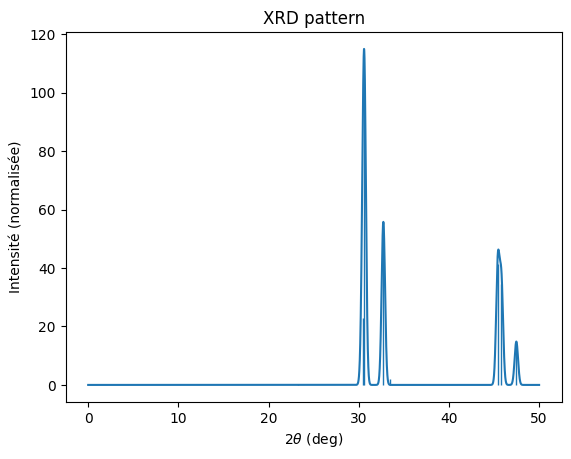

In [55]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

# On va imposer le groupe à la structure pour réduire les erreurs numériques
sga = SpacegroupAnalyzer(structure, symprec=1e-2, angle_tolerance=5)

# Calcul du pattern de diffraction
wavelength = 1.54060
calc = XRDCalculator(wavelength=wavelength)    
pattern = calc.get_pattern(conventional, scaled=True,two_theta_range=(0,50))

two_theta=np.array(pattern.x)
intensity=np.array(pattern.y)
hkls=np.array(pattern.hkls)

# Masque pour retirer les pics d'intensité trop faible (<2,5%)
treshold = 0.025 * intensity.max()  
mask = intensity > treshold
# Filtrage des pics
two_theta_filtered = two_theta[mask]
intensity_filtered = intensity[mask]
hkls_filtered = hkls[mask]

# Tracer la courbe gausienne continue
tt_grid = np.linspace(0, 50, 6000)  
y_cont = gaussian_broaden(two_theta_filtered, intensity_filtered, tt_grid, sigma=0.20)

plt.figure()
plt.plot(tt_grid, y_cont)                
plt.vlines(two_theta, 0, intensity, linewidth=1)  
plt.xlabel(r"$2\theta$ (deg)")
plt.ylabel("Intensité (normalisée)")
plt.title("XRD pattern")
plt.show()





Le diffractogramme présente les 3 premiers pics aux angles approximatifs suivants: 31, 33, 46 degrés.
\
Grossisons le spectrogramme pour voir plus précisément quels plans (hkl) génèrent ces pics.

In [ ]:
fig = pmv.xrd_pattern(pattern,peak_width=0.1)


fig.update_traces(
    marker_color="black",
    marker_line_color="black",
    marker_line_width=1
)
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.update_xaxes(range=[28,47])

In [ ]:
peaks_data = [
    {
        "Pic": 1,
        "2θ (°)": f"{two_theta_filtered[0]:.2f} / {two_theta_filtered[1]:.2f}",
        "Intensité": f"{intensity_filtered[0]:.2f} / {intensity_filtered[1]:.2f}",
        "hkl": f"{hkls_filtered[0][0]['hkl']} (m={hkls_filtered[0][0]['multiplicity']}) / {hkls_filtered[1][0]['hkl']} (m={hkls_filtered[1][0]['multiplicity']})"
    },
    {
        "Pic": 2,
        "2θ (°)": f"{two_theta_filtered[2]:.2f}",
        "Intensité": f"{intensity_filtered[2]:.2f}",
        "hkl": f"{hkls_filtered[2][0]['hkl']} (m={hkls_filtered[2][0]['multiplicity']})"
    },
    {
        "Pic": 3,
        "2θ (°)": f"{two_theta_filtered[3]:.2f} / {two_theta_filtered[4]:.2f}",
        "Intensité": f"{intensity_filtered[3]:.2f} / {intensity_filtered[4]:.2f}",
        "hkl": f"{hkls_filtered[3][0]['hkl']} (m={hkls_filtered[3][0]['multiplicity']}) / {hkls_filtered[4][0]['hkl']} (m={hkls_filtered[4][0]['multiplicity']})"
    }
]

df_peaks = pd.DataFrame(peaks_data)
display(df_peaks)
print("m: multiplicité")
print("*l'intensité est normalisée avec le pic le plus intense prenant la valeur 100")

,Pic,2θ (°),Intensité,hkl
0,1,30.43 / 30.62,22.90 / 100.00,"(1, 0, 1) (m=4) / (1, 1, 0) (m=4)"
1,2,32.73,55.82,"(0, 0, 2) (m=2)"
2,3,45.42 / 45.82,41.40 / 34.54,"(1, 1, 2) (m=8) / (1, 2, 1) (m=8)"


m: multiplicité
*l'intensité est normalisée avec le pic le plus intense prenant la valeur 100


##### Analyse et interprétation des résultats

Le premier pic est generé par les plans (1,0,1) et (1,1,0). La contribution au pic des deux plans est caractérisée par un angle légèrement différent du fait que $d_{101} < d_{110}$.  
En effet:

In [ ]:
def d_hkl(G):
    return 2*np.pi / np.linalg.norm(G)

# Vecteurs du réseau réciproque
K_101 = K_from_hkl(1,0,1,recp_matrix)
K_110 = K_from_hkl(1,1,0,recp_matrix)

d_101 = d_hkl(K_101)
d_110 = d_hkl(K_110)

print(f"d_101: {d_101:.3f}")
print(f"d_110: {d_110:.3f}")

# Calculons la différence d'angle a partir de Bragg
theta_101 = np.rad2deg(np.arcsin(wavelength/(2*d_101)))
theta_110 = np.rad2deg(np.arcsin(wavelength/(2*d_110)))
print(f"Delta 2*theta = {2*(theta_110 - theta_101):.3f}")

print("Nous retrouvons bien la différence d'angle du diffractograme")


d_101: 2.935
d_110: 2.918
Delta 2*theta = 0.186
Nous retrouvons bien la différence d'angle du diffractograme


En ce qui concerne la différence importante d'intensité entre les plans (101) et (110) elle peut être expliquée par l'analyse du facteur de structure de la maille. Avant de calculer celui-ci, nous avons besoins des facteurs de forme atomique.
Nous pouvons les estimer sous l'hypothèse d'une densité électronique sphérique symmétrique autour du noyau en utilisant la formule suivante:
$$
f(|\vec{K}|) = \sum_{i=1}^{4} a_i \exp\left(-b_i \left(\frac{K}{4\pi}\right)^2 \right) + c
$$

avec les valeurs des coefficients:

| Element | a1 | b1 | a2 | b2 | a3 | b3 | a4 | b4 | c |
|--------|----|----|----|----|----|----|----|----|----|
| Na | 4.7626 | 3.285 | 3.1736 | 8.8422 | 1.2674 | 0.3136 | 1.1128 | 129.424 | 0.676 |
| O  | 3.0485 | 13.2771 | 2.2868 | 5.7011 | 1.5463 | 0.3239 | 0.867 | 32.9089 | 0.2508 |
| N  | 12.2126 | 0.0057 | 3.1322 | 9.8933 | 2.0125 | 28.9975 | 1.1663 | 0.5826 | -11.529 |

La formule et les coefficients sont issus de:
[Graz Center of Physics](https://lampz.tugraz.at/~hadley/ss1/crystaldiffraction/atomicformfactors/formfactors.php)


In [ ]:
atoms = ["Na", "O", "N"]

a = {
    "Na": [4.7626, 3.1736, 1.2674, 1.1128],
    "O":  [3.0485, 2.2868, 1.5463, 0.867],
    "N":  [12.2126, 3.1322, 2.0125, 1.1663]
}

b = {
    "Na": [3.285, 8.8422, 0.3136, 129.424],
    "O":  [13.2771, 5.7011, 0.3239, 32.9089],
    "N":  [0.0057, 9.8933, 28.9975, 0.5826]
}

c = {
    "Na": 0.676,
    "O": 0.2508,
    "N": -11.529
}

def atomic_form_factor(Knorm, atom):
    """
    Calcule le facteur d'onde atomique sur base de la norme d'un vecteur K 
    du réseau réciproque et de l'atome considéré
    """
    s = Knorm / (4*np.pi)
    
    ai = a[atom]
    bi = b[atom]
    ci = c[atom]

    f = 0
    for i in range(4):
        f += ai[i] * np.exp(-bi[i] * s**2)

    return f + ci

À partir de l'estimation du facteur de forme atomique $f_j(|\mathbf{K}|)$, on peut calculer le facteur de structure de la maille :

$$
S_{\mathbf{G}} = \sum_{j=1}^{N} f_j(|\mathbf{G}|)\, e^{i\,\mathbf{G}\cdot \mathbf{r}_j}
$$

In [ ]:
def structure_factor(h,k,l, Knorm, atoms):
    """
    Calcule le facteur de structure pour un vecteur K
    atoms: list de dictionnaires comme: {"element": "Na", "pos"= (x,y,z)}
    """

    S = 0.0 + 0.0j

    for atom in atoms:
        element = atom["element"]
        x,y,z = atom["pos"]

        fj = atomic_form_factor(Knorm, element)
        phase = np.exp(1j * 2 * np.pi * (h*x + k*y + l*z))

        S += fj*phase
        
    return S

print_title("Résultats")
 
S_101 = structure_factor(1,0,1,np.linalg.norm(K_101),atoms_conv)
S_110 = structure_factor(1,1,0,np.linalg.norm(K_110),atoms_conv)

# Multiplicité des pics
m_101 = hkls_filtered[0][0]['multiplicity']
m_110 = hkls_filtered[1][0]['multiplicity']

I_101 = m_101*abs(S_101)**2
I_110 = m_110*abs(S_110)**2

print("S_101 =", S_101)
print("S_110 =", S_110)
print("I_101 =", I_101)
print("I_110 =", I_110)
print(f"Intensité relative de I_101 par rapport à I_110 = {(I_101 / I_110)*100:.1f}")


Résultats
---------
S_101 = (16.688364182023832-1.9857164249280848j)
S_110 = (35.31825413647317-7.105427357601002e-15j)
I_101 = 1129.7782751683405
I_110 = 4989.516300994017
Intensité relative de I_101 par rapport à I_110 = 22.6


L'intensité relative correspond à quelques dizièmes à celle du diffractogramme. La même analyse peut être effectuée pour les autres pics. Nous pouvons par exemple vérifier l'extinction du pic (100) qui ne répond pas à la condition : $$ h = 2n$$

In [ ]:
K_100 = K_from_hkl(1,0,0,recp_matrix)
S_100 = structure_factor(1,0,0,np.linalg.norm(K_100), atoms_conv)
I_100 = abs(S_100)**2
print(f"Intensité relative de I_100 par rapport à I_110 = {(I_100 / I_110)*100}")

Intensité relative de I_100 par rapport à I_110 = 2.314824708465453e-31


#### 5. Structure des bandes électroniques

#### 5.1. Graphe


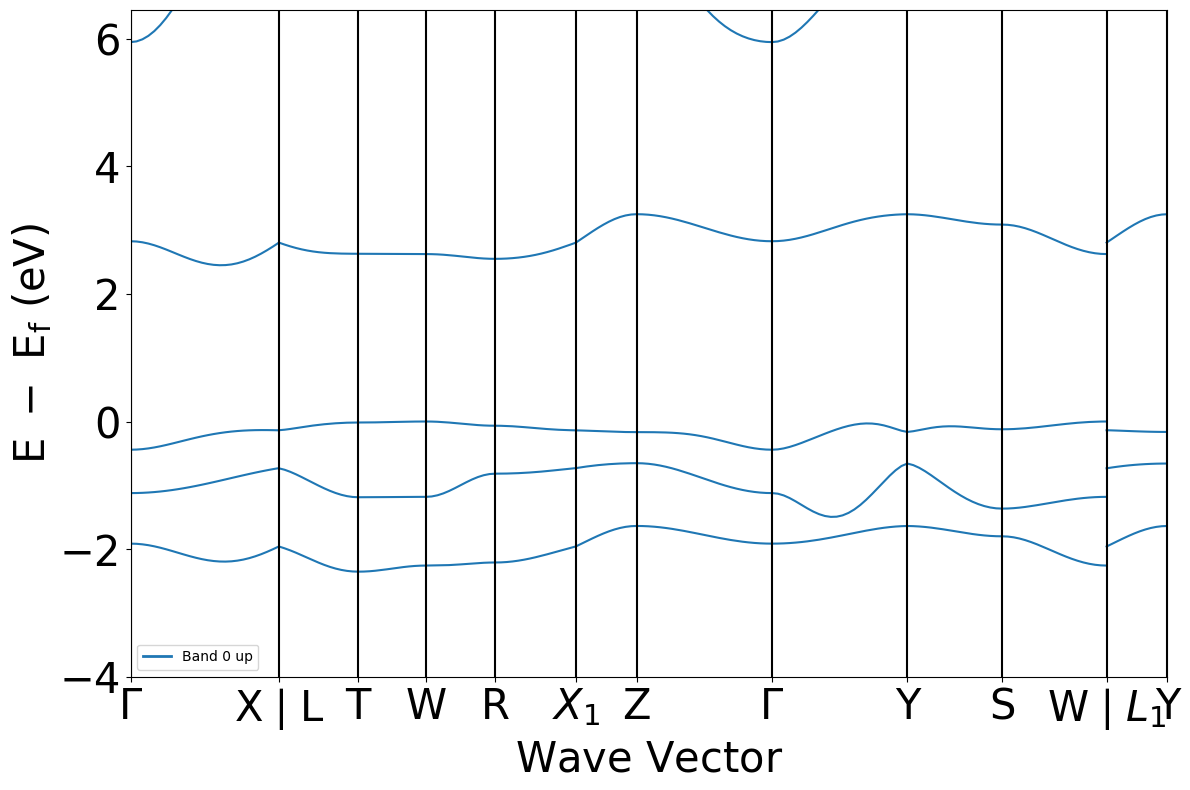

In [ ]:
# bandsstructure téléchargé avant
plotter = BSPlotter(bandstructure)
plotter.get_plot()
plt.show()


#### 5.2 Bande Interdite

Largeur de la bande interdite : 2.4493 eV
Type de matériau : Isolant
Type de bande interdite : indirecte (W-(-0.213,0.213,0.213))
Index de la dernière bande de valence : 11
Index de la première bande de conduction : 12


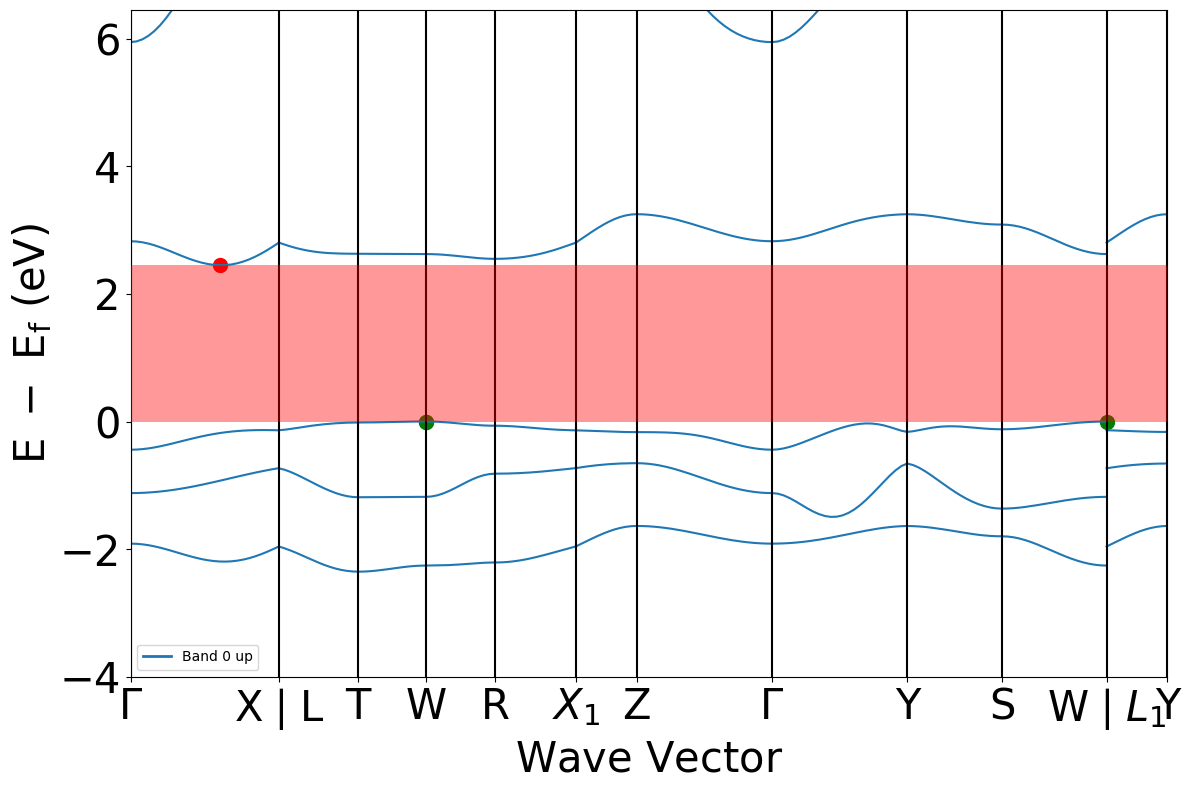

In [ ]:
gap = bandstructure.get_band_gap()
gap_width = gap['energy']
gap_trans = gap['transition']
direct = "directe" if gap['direct'] else "indirecte"
mat_type = "Métal" if bandstructure.is_metal() else "Semi-conducteur" if gap_width <= 1.5 else "Isolant"

print(f"Largeur de la bande interdite : {gap_width} eV")
print(f"Type de matériau : {mat_type}")
print(f"Type de bande interdite : {direct} ({gap_trans})")

bsp = BSPlotter(bandstructure)
data = bsp.bs_plot_data()

# Bandes de valences / Bandes de condution
vb, cb, = bandstructure.get_vbm(), bandstructure.get_cbm()
pos_vb, pos_cb = data['vbm'][0], data['cbm'][0]
n_vb, n_cb = vb['band_index'][Spin.up][0], cb['band_index'][Spin.up][0]
print(f"Index de la dernière bande de valence : {n_vb}")
print(f"Index de la première bande de conduction : {n_cb}")

bsp.get_plot(vbm_cbm_marker=True)
ax=plt.gca()
BI=pch.Rectangle((pos_vb[0] - 5 / 2, pos_vb[1]),10,pos_cb[1] - pos_vb[1],linewidth=0,edgecolor=None,facecolor='red',alpha=0.4,zorder=10)
ax.add_patch(BI)
plt.show()

Nous observons dans la figure ci-dessus la bande interdite représentée en rouge, séparent la bande de valence (sous la bande interdite) et la bande de conduction (au-dessus de la bande interdite)

#### 5.3 Direction de dispersion

In [ ]:
plot_data = BSPlotter(bandstructure).bs_plot_data(zero_to_efermi=True)
distances, energy = plot_data['distances'], plot_data['energy']

mcbs, mvbs = np.inf, np.inf
Mcbs, Mvbs = 0, 0
mcbi = mvbi = Mcbi = Mvbi = 0
arrow_values = [[], [], [], []]  # max cond, max val, min cond, min val

for i, dist in enumerate(distances):
    fd, ld = dist[0], dist[-1]
    delta = ld - fd
    if abs(delta) < 1e-8:
        continue

    fcbE, lcbE = energy['1'][i][n_cb][0], energy['1'][i][n_cb][-1]
    fvbE, lvbE = energy['1'][i][n_vb][0], energy['1'][i][n_vb][-1]
    cbs, vbs = (lcbE - fcbE) / delta, (lvbE - fvbE) / delta

    if abs(cbs) > abs(Mcbs):
        Mcbs, Mcbi = cbs, i
        arrow_values[0] = [fd, fcbE, delta, lcbE - fcbE]
    if abs(vbs) > abs(Mvbs):
        Mvbs, Mvbi = vbs, i
        arrow_values[1] = [fd, fvbE, delta, lvbE - fvbE]
    if abs(cbs) < abs(mcbs):
        mcbs, mcbi = cbs, i
        arrow_values[2] = [fd, fcbE, delta, lcbE - fcbE]
    if abs(vbs) < abs(mvbs):
        mvbs, mvbi = vbs, i
        arrow_values[3] = [fd, fvbE, delta, lvbE - fvbE]

print(f"Pente minimale de la bande de valence : {mvbs}")
print(f"Pente maximale de la bande de valence : {Mvbs}")
print(f"Pente minimale de la bande de conduction : {mcbs}")
print(f"Pente maximale de la bande de conduction : {Mcbs}")

Pente minimale de la bande de valence : 0.028039188116685022
Pente maximale de la bande de valence : 0.24871647079433049
Pente minimale de la bande de conduction : -0.00857249063440037
Pente maximale de la bande de conduction : 0.8865896470045151


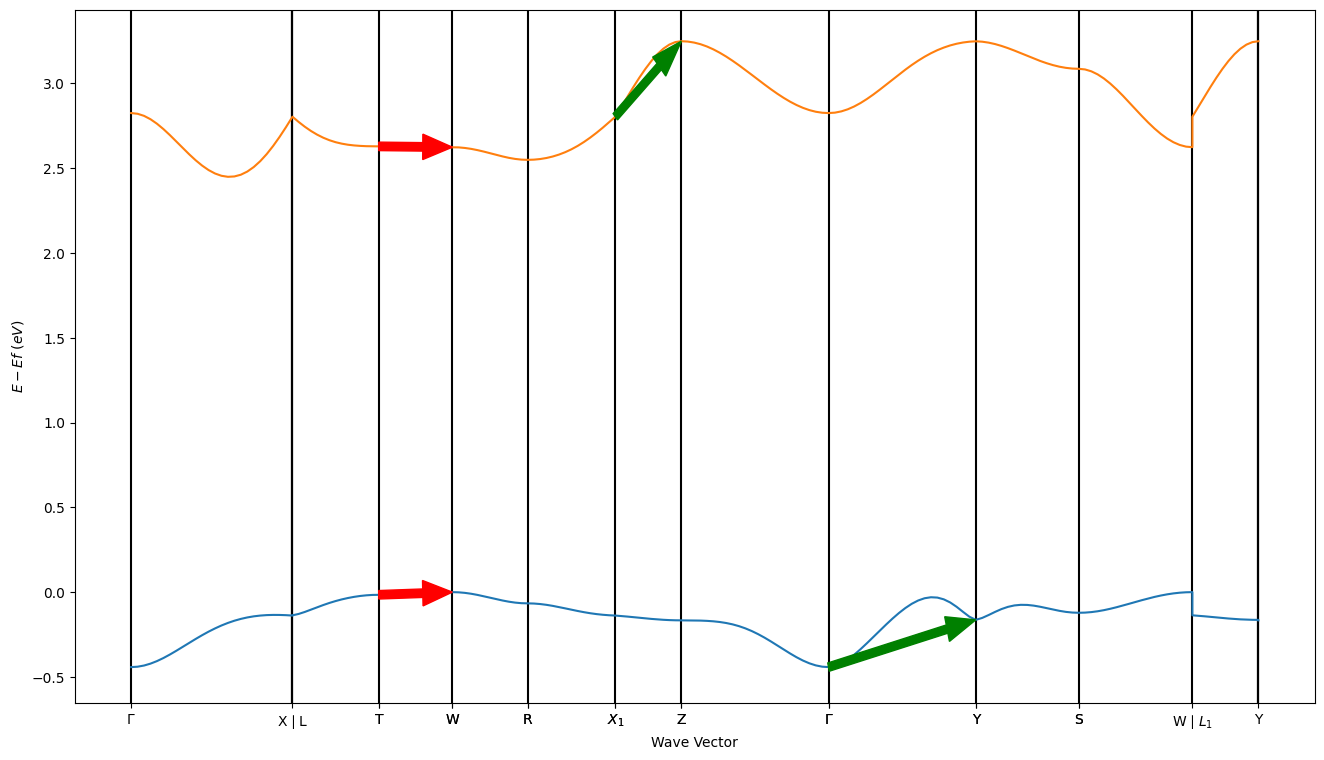

In [ ]:
fig, ax = plt.subplots(figsize=(16,9))

# Vertical bars
vaxis = [d[0] for d in distances]
vaxis.append(distances[-1][-1])

all_distances = np.concatenate(distances)
last_valence_band = np.concatenate([energy['1'][i][n_vb] for i in range(len(distances))])
first_conduction_band = np.concatenate([energy['1'][i][n_cb] for i in range(len(distances))])

# Ticks: préférer ceux de BSPlotter (haute symétrie)
tick_distances = plot_data.get('ticks', {}).get('distance', [])
tick_labels = plot_data.get('ticks', {}).get('label', [])
if len(tick_distances) == len(tick_labels) and len(tick_labels) > 0:
    ax.set_xticks(tick_distances)
    ax.set_xticklabels(tick_labels)
else:
    ax.set_xticks(vaxis)
    ax.set_xticklabels(["" for _ in vaxis])

ax.set_xlabel('Wave Vector')
ax.set_ylabel('$E-Ef$ ($eV$)')

for v in vaxis: plt.axvline(v,color='black')

plt.arrow(arrow_values[0][0],arrow_values[0][1],arrow_values[0][2],arrow_values[0][3],zorder=10,length_includes_head=True, width = .05, color='green') # max conduction band slope
plt.arrow(arrow_values[1][0],arrow_values[1][1],arrow_values[1][2],arrow_values[1][3],zorder=10,length_includes_head=True, width = .05, color='green') # max valence band slope
plt.arrow(arrow_values[2][0],arrow_values[2][1],arrow_values[2][2],arrow_values[2][3],zorder=10,length_includes_head=True, width = .05, color='red')   # min conduction band slope
plt.arrow(arrow_values[3][0],arrow_values[3][1],arrow_values[3][2],arrow_values[3][3],zorder=10,length_includes_head=True, width = .05, color='red')   # min valence band slope

plt.plot(all_distances,last_valence_band)
plt.plot(all_distances,first_conduction_band)

plt.show()

Pour effectuer les calculs, on a calculé la pente récursivement sur chaque segment.

#### 5.4 Masse effective

In [ ]:
# Masse effective via la définition simple: 1/m* = (1/hbar^2) d^2E/dk^2
hbar = 1.054_571_817e-34  # J.s
eV_to_J = 1.602_176_634e-19
m_e = 9.109_383_7015e-31  # kg

# Energies des bandes (nbands, nkpoints)
energies = bandstructure.bands[Spin.up]

# Coordonnées k cartésiennes (supposées en 1/Angstrom dans pymatgen) -> conversion en 1/m
k_cart = np.array([kp.cart_coords for kp in bandstructure.kpoints], dtype=float) * 1e10

def local_effective_mass(energies_eV, k_vectors_1m, i0, window=2):
    """
    Estime m* au voisinage de i0 en ajustant E(s)=a s^2+b s+c,
    où s est la distance curviligne locale le long du chemin en k.
    """
    i_start = max(0, i0 - window)
    i_end = min(len(energies_eV), i0 + window + 1)
    idx = np.arange(i_start, i_end)

    if len(idx) < 3:
        raise ValueError("Pas assez de points pour estimer une dérivée seconde.")

    # Distance curviligne locale signée autour de i0
    s = np.zeros(len(idx), dtype=float)
    center = np.where(idx == i0)[0][0]

    for j in range(center + 1, len(idx)):
        ds = np.linalg.norm(k_vectors_1m[idx[j]] - k_vectors_1m[idx[j - 1]])
        s[j] = s[j - 1] + ds
    for j in range(center - 1, -1, -1):
        ds = np.linalg.norm(k_vectors_1m[idx[j + 1]] - k_vectors_1m[idx[j]])
        s[j] = s[j + 1] - ds

    # Suppression des points dupliqués en k (jonctions de segments haute symétrie)
    mask_unique = np.ones(len(s), dtype=bool)
    for j in range(1, len(s)):
        if np.isclose(s[j], s[j - 1], rtol=0.0, atol=1e-14):
            mask_unique[j] = False

    s_fit = s[mask_unique]
    E_fit_J = energies_eV[idx][mask_unique] * eV_to_J

    if len(s_fit) < 3:
        raise ValueError("Points k locaux insuffisants après retrait des duplicats.")

    # Ajustement quadratique: E = a s^2 + b s + c
    a, b, c = np.polyfit(s_fit, E_fit_J, deg=2)
    d2E_dk2 = 2.0 * a

    if abs(d2E_dk2) < 1e-60:
        raise ValueError("Courbure numériquement trop faible: masse effective non fiable.")

    return (hbar ** 2) / d2E_dk2

vb = bandstructure.get_vbm()
cb = bandstructure.get_cbm()

# Indices de bande / k-point
n_vb = vb['band_index'][Spin.up][0]
n_cb = cb['band_index'][Spin.up][0]
i_vb = vb['kpoint_index'][0]
i_cb = cb['kpoint_index'][0]

m_vb = local_effective_mass(energies[n_vb], k_cart, i_vb, window=2)
m_cb = local_effective_mass(energies[n_cb], k_cart, i_cb, window=2)

print("Masses effectives:")
print(f"- Bande de valence (electron): {m_vb:.3e} kg.")
print(f"- Bande de conduction        : {m_cb:.3e} kg.")

Masses effectives:
- Bande de valence (electron): -1.462e-29 kg.
- Bande de conduction        : 2.110e-30 kg.


La masse effective est la masse des particules compensé par les forces agissant dessus, générées notamment par le potentiel périodique. La masse de l'electron dans la bande de valance à un signe négatif car il accélère à l'opposé de la direction principale utilisée pour les calculs. On pourrait considérer les trous (emplacement vide) et avoir une masse positive

#### 6. Phonons


#### 6.1 Graphe


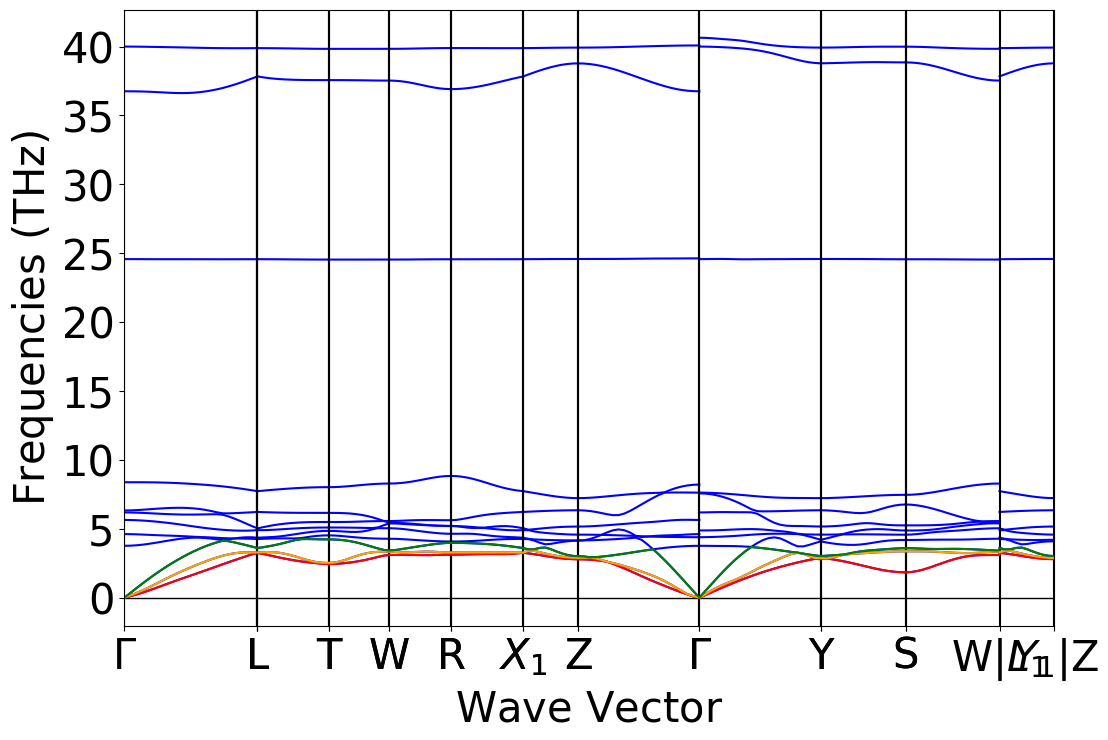

In [ ]:
plotter = PhononBSPlotter(phononbandstructure.to_pmg)
plot_data = plotter.bs_plot_data()

distances = plot_data['distances'] # distances[segment][k_point]
frequence = plot_data['frequency'] # frequency[segment][band(or 'mode')][k_point]

plotter.get_plot()
for i in range(len(distances)):
    plt.plot(distances[i], frequence[i][0], color = 'red')
    plt.plot(distances[i], frequence[i][1], color = 'orange')
    plt.plot(distances[i], frequence[i][2], color = 'green')

La vitesse du son peut être calculée par $\frac{d\omega}{dk}\vert_{\omega \rightarrow 0}$.  
On peut remarquer sur le graphe ci-dessus que les fréquences des bandes choisies ne s'annulent qu'en $\Gamma$.

On va donc calculer la vitesse du son selon les directions de la zone de Brillouin:
- $\Gamma \rightarrow Z$
- $\Gamma \rightarrow L$
- $\Gamma \rightarrow X$

#### 6.2 Vitesse du son

In [ ]:
THZ_TO_RAD_S = 2.0 * np.pi * 1e12
ANG_TO_M = 1e10

def _clean_label(lbl):
    """Nettoie les labels latex de ticks pour faciliter la comparaison."""
    if lbl is None:
        return ""
    return str(lbl).replace("$", "").replace("\\Gamma", "Γ").replace("\\", "").strip()

def sound_speed_segment(mode, seg_idx, from_start=True, n_points=4):
    """
    Calcule v = dω/dk sur un segment en ajustant linéairement les premiers points.
    """
    d = np.array(distances[seg_idx], dtype=float)
    f = np.array(frequence[seg_idx][mode], dtype=float)

    if not from_start:
        d = d[::-1]
        f = f[::-1]

    k_local = (d - d[0]) * ANG_TO_M
    omega_local = f * THZ_TO_RAD_S

    pos_idx = np.where(k_local > 0)[0]
    if len(pos_idx) < 1:
        return np.nan

    take_pos = pos_idx[: max(1, n_points - 1)]
    sel = np.r_[0, take_pos]
    k_sel = k_local[sel]
    w_sel = omega_local[sel]

    uniq_mask = np.r_[True, np.diff(k_sel) > 0]
    k_sel = k_sel[uniq_mask]
    w_sel = w_sel[uniq_mask]

    if len(k_sel) < 2:
        return np.nan

    slope, _ = np.polyfit(k_sel, w_sel, 1)
    return abs(slope) #si moins, la direction est inversée, mais on veut la vitesse 

mode = 0  # garder seulement le mode acoustique 0
gamma_labels = {"Γ", "Gamma", "G"}

bs_ph = phononbandstructure.to_pmg
branches = getattr(bs_ph, "branches", [])

# Stocke toutes les directions calculables (réelles)
all_dir_vs = {}
for i, br in enumerate(branches[:len(distances)]):
    name = br.get("name", "")
    if "-" not in name:
        continue

    left_raw, right_raw = name.split("-", 1)
    left, right = _clean_label(left_raw), _clean_label(right_raw)
    if left == right:
        continue

    direction = f"{left} -> {right}"
    if direction in all_dir_vs:
        continue

    v = sound_speed_segment(mode, i, from_start=True, n_points=4)
    if np.isfinite(v):
        all_dir_vs[direction] = v

# Priorité: directions depuis Γ, puis complément avec autres directions réelles
preferred_gamma = ["Γ -> X", "Γ -> Y", "Γ -> Z"]
selected = [d for d in preferred_gamma if d in all_dir_vs]
for d in all_dir_vs:
    if d not in selected:
        selected.append(d)
    if len(selected) == 3:
        break

results = [{"direction": d, "mode": 0, "v_s (m/s)": all_dir_vs[d]} for d in selected]
df_vs = pd.DataFrame(results)
display(df_vs)

,direction,mode,v_s (m/s)
0,Γ -> X,0,1360.443232
1,Γ -> Y,0,2145.190053
2,L -> T,0,1013.180894
